<a href="https://colab.research.google.com/github/uthman98/Using-recount/blob/main/survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Example: Training a Simple Machine Learning Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification

# Set random seed for reproducibility
np.random.seed(42)

### 1. Generate a Synthetic Dataset

We'll create a binary classification dataset with two informative features.

Shape of features (X): (1000, 2)
Shape of target (y): (1000,)


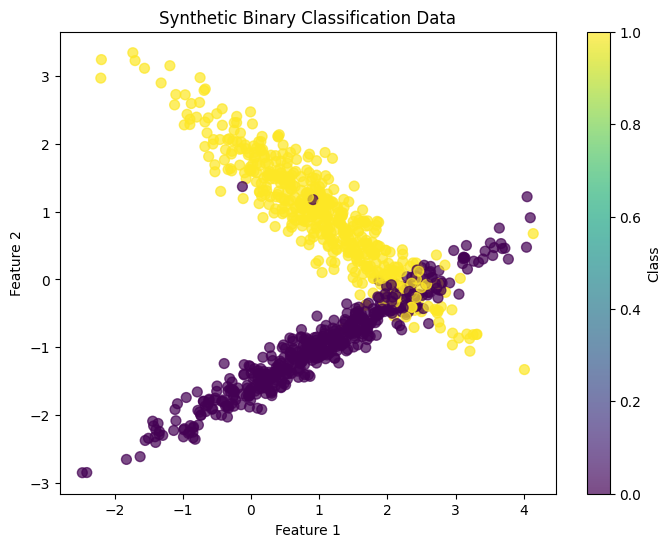

In [ ]:
# Generate synthetic data for binary classification
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.title('Synthetic Binary Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.show()

### 2. Split Data into Training and Testing Sets

It's crucial to split data to evaluate the model's performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 700 samples
Testing set size: 300 samples


### 3. Train a Simple Machine Learning Model (Logistic Regression)

We'll use a Logistic Regression model for this binary classification task.

In [ ]:
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### 4. Make Predictions and Evaluate the Model

After training, we evaluate how well our model performs on the test set.

Accuracy: 0.88

Confusion Matrix:
[[137  10]
 [ 25 128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       147
           1       0.93      0.84      0.88       153

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300



/tmp/ipykernel_1181/2300444847.py:21: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='r', marker='x', s=100, label='Test Data')


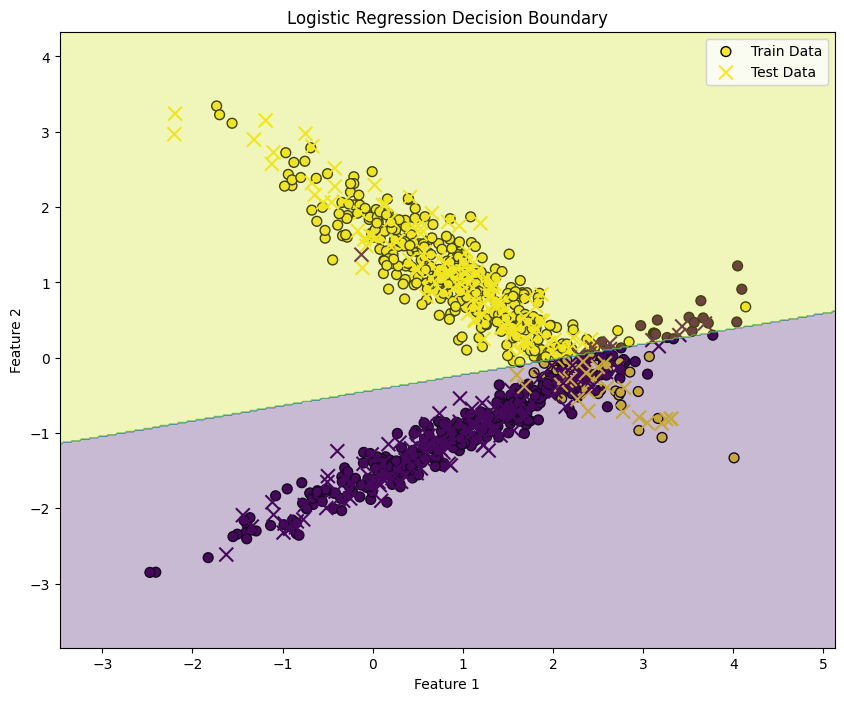

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize the decision boundary (for 2D data)
plt.figure(figsize=(10, 8))

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, label='Train Data')
# Plot the test points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='r', marker='x', s=100, label='Test Data')

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("clinical_data.csv")

print(df.head())
print(df.shape)
print(df.dtypes)

     PATIENT_ID   TENM3  MAP1LC3B  DIRAS3 OS_STATUS   OS_MONTHS  status  \
0  TCGA-3C-AAAU -0.3246    0.8574 -0.1901  0:LIVING  132.950066       0   
1  TCGA-3C-AALI -0.4186    0.3700 -0.1781  0:LIVING  131.570302       0   
2  TCGA-3C-AALJ -0.3983   -0.3430 -0.1688  0:LIVING   48.423127       0   
3  TCGA-3C-AALK  1.6979   -0.6177  0.2339  0:LIVING   47.568988       0   
4  TCGA-4H-AAAK  1.1081   -0.5160 -0.1403  0:LIVING   11.432326       0   

  TENM3p DIRAS3p MAP1LC3Bp  
0   High     Low      High  
1   High     Low       Low  
2   High     Low       Low  
3   High    High       Low  
4   High    High       Low  
(1090, 10)
PATIENT_ID     object
TENM3         float64
MAP1LC3B      float64
DIRAS3        float64
OS_STATUS      object
OS_MONTHS     float64
status          int64
TENM3p         object
DIRAS3p        object
MAP1LC3Bp      object
dtype: object


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c3e5379e5f7692f73a66201e854f2ab78ae06d5cd38c2113605a67ca0a48e404
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

df = df.dropna(subset=["OS_MONTHS", "status"])
print(df.head())
print(df.shape)


kmf = KaplanMeierFitter()

kmf.fit(durations = df["OS_MONTHS"], event_observed = df["status"])

kmf.plot_survival_function
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.savefig("km_plot.pdf", dpi = 300, bbox_inches = "tight")

Log-rank p-value: 0.0780


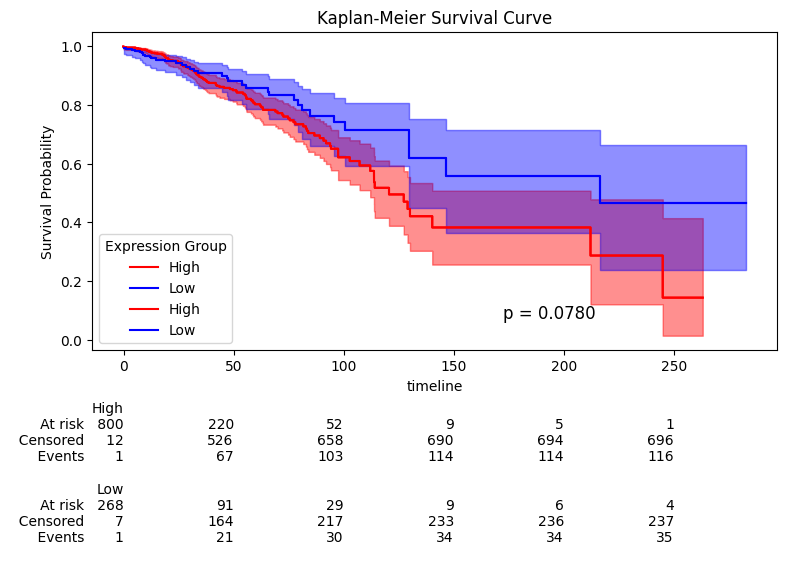

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

fig, ax = plt.subplots(figsize = (8,6))
kmf = KaplanMeierFitter()

for group, color in zip(["High", "Low"], ["red", "blue"]):
  mask = df["TENM3p"] == group
  kmf.fit(durations = df.loc[mask, "OS_MONTHS"],
         event_observed = df.loc[mask, "status"],
         label = group)
  kmf.plot_survival_function(ax=ax, color = color, ci_show = True)

  plt.title("Kaplan-Meier Survival Curve")
  plt.xlabel("Time (months)")
  plt.ylabel("Survival Probability")
  plt.legend(title = "Expression Group")
  plt.savefig("km_plot.pdf", dpi = 300, bbox_inches = "tight")

high_group = df[df["TENM3p"] == "High"]
low_group = df[df["TENM3p"] == "Low"]

results = logrank_test(high_group["OS_MONTHS"], low_group["OS_MONTHS"],
                       high_group["status"], low_group["status"],
                       alpha = 0.95)

p_value = results.p_value
print(f"Log-rank p-value: {p_value:.4f}")

plt.text(0.6,0.1, f"p = {p_value:.4f}", transform = ax.transAxes, fontsize = 12)

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(high_group["OS_MONTHS"], high_group["status"], label = "High")
kmf_low.fit(low_group["OS_MONTHS"], low_group["status"], label = "Low")

kmf_high.plot_survival_function(ax=ax, color = "red")
kmf_low.plot_survival_function(ax=ax, color = "blue")
add_at_risk_counts(kmf_high, kmf_low, ax=ax, color = "black")

plt.tight_layout()
plt.savefig("km_plot_with_risk_table.pdf", dpi = 300, bbox_inches = "tight")


### Combined Survival Analysis Workflow

DataFrame shape after dropping NaNs: (1089, 10)

Log-rank p-value: 0.0780


/tmp/ipykernel_1181/1382803122.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Expression Group")


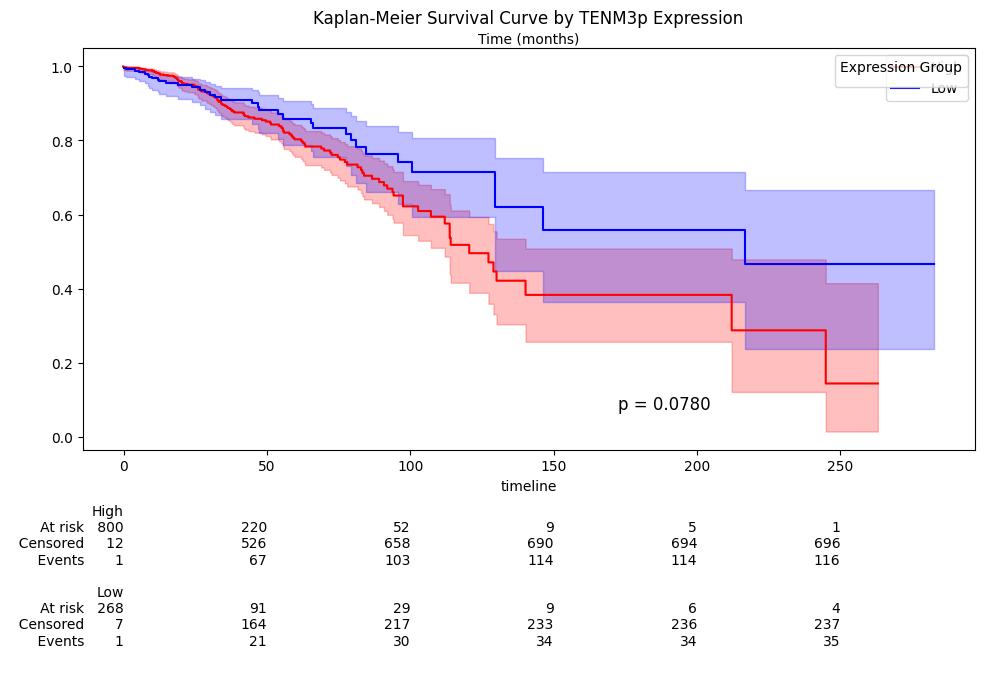


--- Survival Summary Statistics ---
High: At risk (initial): 813, Censored: 697, Events: 116
Low: At risk (initial): 276, Censored: 241, Events: 35


In [ ]:
from numpy._core.fromnumeric import size
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

# 1. Load Data (assuming 'clinical_data.csv' is in the current directory)
df = pd.read_csv("clinical_data.csv")

# 2. Preprocessing: Drop rows with NaN values in 'OS_MONTHS' or 'status'
df = df.dropna(subset=["OS_MONTHS", "status"])
print("DataFrame shape after dropping NaNs:", df.shape)

# 3. Create Kaplan-Meier Plot for 'High' and 'Low' TENM3p groups
fig, ax = plt.subplots(figsize=(10, 7))

# Instantiate KaplanMeierFitter objects for each group
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# Filter data for each group
high_group = df[df["TENM3p"] == "High"]
low_group = df[df["TENM3p"] == "Low"]

# Fit and plot for 'High' group
kmf_high.fit(durations=high_group["OS_MONTHS"],
             event_observed=high_group["status"],
             label="High")
kmf_high.plot_survival_function(ax=ax, color="red", ci_show=True)

# Fit and plot for 'Low' group
kmf_low.fit(durations=low_group["OS_MONTHS"],
            event_observed=low_group["status"],
            label="Low")
kmf_low.plot_survival_function(ax=ax, color="blue", ci_show=True)

# Add 'at-risk' table below the plot
add_at_risk_counts(kmf_high, kmf_low, ax=ax, color="black")

plt.title("Kaplan-Meier Survival Curve by TENM3p Expression")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.legend(title="Expression Group")

# 4. Perform Log-Rank Test
results = logrank_test(high_group["OS_MONTHS"], low_group["OS_MONTHS"],
                       high_group["status"], low_group["status"],
                       alpha=0.95)

p_value = results.p_value
print(f"\nLog-rank p-value: {p_value:.4f}")

# Add p-value to the plot
plt.text(0.6, 0.1, f"p = {p_value:.4f}", transform=ax.transAxes, fontsize=12)

plt.tight_layout()

# 5. Save the plot
plt.savefig("km_plot_combined_with_risk_table.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Calculate and print summary statistics
print("\n--- Survival Summary Statistics ---")

# High Group
high_at_risk_initial = len(high_group)
high_censored = (high_group['status'] == 0).sum()
high_events = (high_group['status'] == 1).sum()
print(f"High: At risk (initial): {high_at_risk_initial}, Censored: {high_censored}, Events: {high_events}")

# Low Group
low_at_risk_initial = len(low_group)
low_censored = (low_group['status'] == 0).sum()
low_events = (low_group['status'] == 1).sum()
print(f"Low: At risk (initial): {low_at_risk_initial}, Censored: {low_censored}, Events: {low_events}")